In [1]:
import numpy as np
import pandas as pd 
from epiweeks import Week 
import matplotlib.pyplot as plt 
from viz import plot_zoom_state
from aux_func import get_data, rename_models, code_to_state, color_palette

Load data:

In [2]:
challenge = 'dengue_state'

df_dengue = get_data(challenge)
df_dengue.date = pd.to_datetime(df_dengue.date)

df_dengue.head()

,date,adm_1,casos
0,2010-01-03,11,2456
1,2010-01-03,12,760
2,2010-01-03,13,155
3,2010-01-03,14,25
4,2010-01-03,15,115


Load preds: 

In [3]:
df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds['model'] = df_preds['model'].replace(rename_models)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,ISI
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,ISI
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,ISI
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,ISI
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,ISI


Load rank: 

In [4]:
df_rank = pd.read_csv(f'predictions/rank_ratio_{challenge}.csv.gz')
df_summary = (
    df_rank
    .groupby(["adm_1", "model"], as_index=False)
    .agg(
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_1", "geometric_mean_ratio"])
)
df_summary['model'] = df_summary['model'].replace(rename_models)

df_summary.head()

,adm_1,model,geometric_mean_ratio
6,11,EMAP_SARIMAX,0.769598
20,11,PUCRIO,0.789304
16,11,LNCC_ARP26,0.800598
13,11,IFGW,0.845450
22,11,RKI_PH,0.893327


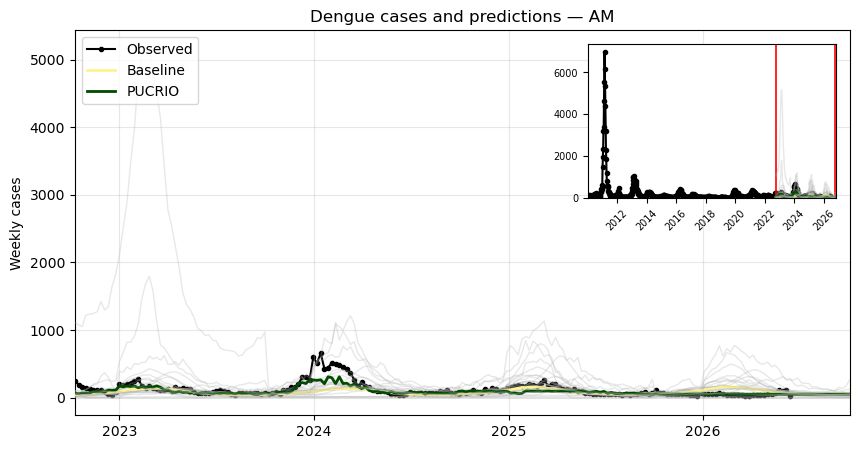

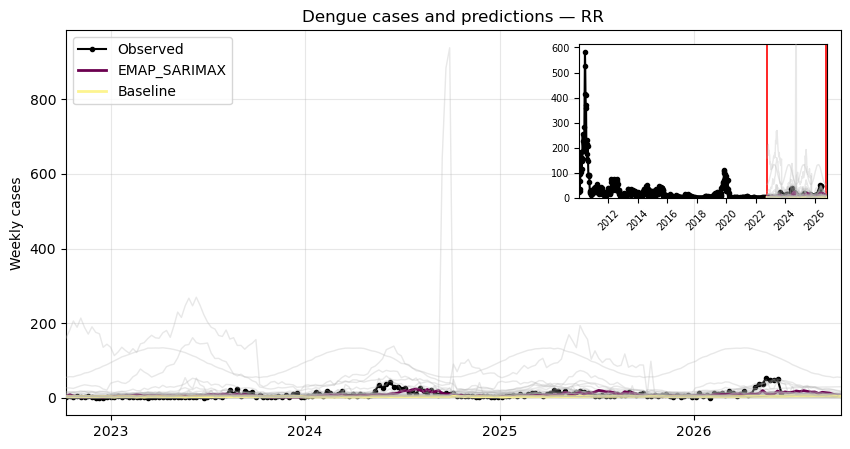

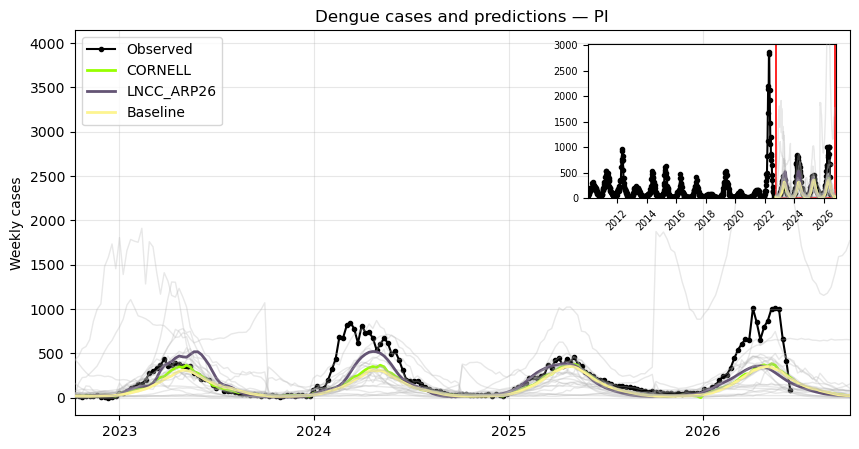

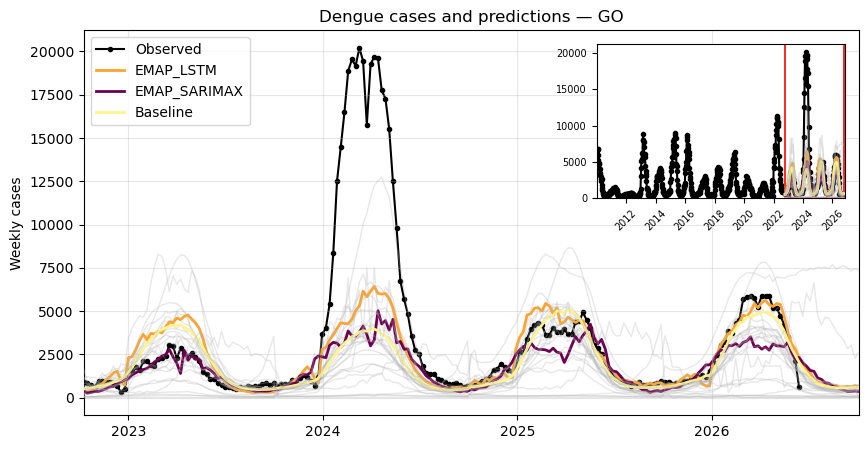

In [7]:
zoom_start = pd.to_datetime(Week(2022,41).startdate())
zoom_end = pd.to_datetime(Week(2026,40).startdate())

for state in [13,14, 22, 52]: 
    plot_zoom_state(
        state,
        df_dengue,
        df_preds,
        df_summary,
        code_to_state,
        color_palette,
        zoom_start,
        zoom_end,
        model_base="PROCC",
        figsize=(10, 5),
        savepath=f'figures/zoom_{state}_{challenge}.png'
        )

    plt.show()